In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import numpy as np

from src.utils import paths
from src.utils.helpers import get_dataframe
from src.utils.plots import get_heatmap, get_line, get_kde

import pandas as pd
from matplotlib import pyplot as plt

import seaborn as sns

In [3]:
cwd = os.getcwd()
print(f'cwd = {cwd}')
cwd += '/../'

cwd = D:\venv\src\lg18650hg2\notebooks


In [4]:
features = ['V', 'I', 'Temp', 'V_avg', 'I_avg']
targets = ['SOC']

train_raw_data_dir = os.path.join(cwd, paths.train_raw_data_dir)
val_raw_data_dir = os.path.join(cwd, paths.val_raw_data_dir)
test_raw_data_dir = os.path.join(cwd, paths.test_raw_data_dir)

train_raw_data_list_dir = os.listdir(train_raw_data_dir)
val_raw_data_list_dir = os.listdir(val_raw_data_dir)
test_raw_data_list_dir = os.listdir(test_raw_data_dir)

print(f'train_raw_data_list_dir = {train_raw_data_list_dir}')
print(f'train_raw_data_list_dir = {val_raw_data_list_dir}')
print(f'train_raw_data_list_dir = {test_raw_data_list_dir}')

train_raw_data_list_dir = ['TRAIN_LGHG2@n10degC_to_25degC_Norm_5Inputs.csv']
train_raw_data_list_dir = ['01_TEST_LGHG2@n10degC_Norm_(05_Inputs).csv']
train_raw_data_list_dir = ['02_TEST_LGHG2@0degC_Norm_(05_Inputs).csv', '03_TEST_LGHG2@10degC_Norm_(05_Inputs).csv', '04_TEST_LGHG2@25degC_Norm_(05_Inputs).csv']


In [5]:
train_raw_data = get_dataframe(
    dir_path=train_raw_data_dir, 
    listdir=train_raw_data_list_dir
)

train_raw_data

,V,I,Temp,V_avg,I_avg,SOC
0,0.385148,0.75102,0.303101,0.385148,0.75102,0.206417
1,0.385152,0.75102,0.304591,0.385150,0.75102,0.206417
2,0.385156,0.75102,0.306081,0.385152,0.75102,0.206417
3,0.385160,0.75102,0.307572,0.385154,0.75102,0.206417
4,0.385164,0.75102,0.309062,0.385156,0.75102,0.206417
...,...,...,...,...,...,...
669951,0.478843,0.75102,0.008477,0.459558,0.75102,0.283243
669952,0.478843,0.75102,0.008477,0.459699,0.75102,0.283243
669953,0.478843,0.75102,0.008477,0.459839,0.75102,0.283243
669954,0.478961,0.75102,0.008477,0.459979,0.75102,0.283243


In [6]:
train_raw_data.describe()

,V,I,Temp,V_avg,I_avg,SOC
count,669956.000000,669956.000000,669956.000000,669956.000000,669956.000000,669956.000000
mean,0.710843,0.752365,0.672214,0.710363,0.752353,0.640461
std,0.252053,0.079163,0.332360,0.247668,0.056138,0.333134
min,0.000158,0.000000,0.002811,0.176340,0.597627,0.062822
25%,0.484394,0.751020,0.322932,0.484137,0.724062,0.292033
50%,0.749018,0.751020,0.915628,0.748360,0.751020,0.702539
75%,0.970067,0.762989,0.925131,0.969918,0.754660,0.993671
max,1.000000,1.000000,0.985835,0.977572,0.875519,1.000436


In [7]:
train_raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669956 entries, 0 to 669955
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V       669956 non-null  float64
 1   I       669956 non-null  float64
 2   Temp    669956 non-null  float64
 3   V_avg   669956 non-null  float64
 4   I_avg   669956 non-null  float64
 5   SOC     669956 non-null  float64
dtypes: float64(6)
memory usage: 30.7 MB


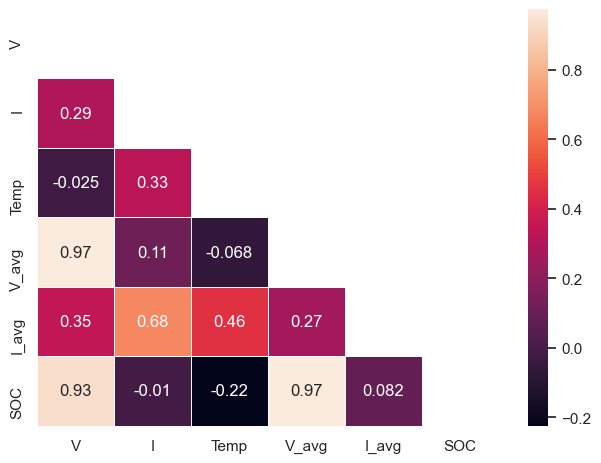

In [8]:
get_heatmap(corr=train_raw_data.corr(), path=os.path.join(cwd, paths.heatmaps_dir, 'train_raw_data_heatmap.png'))

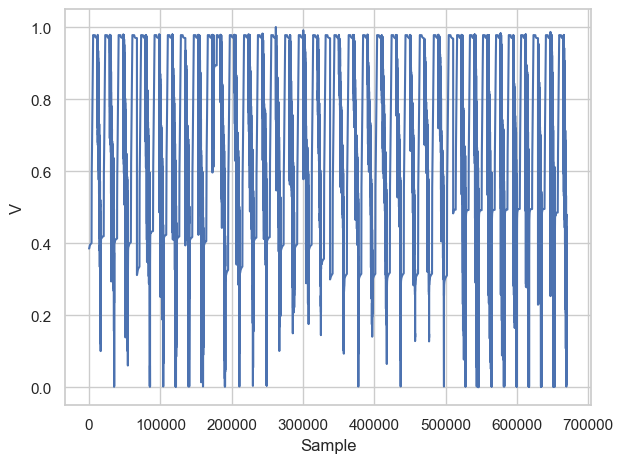

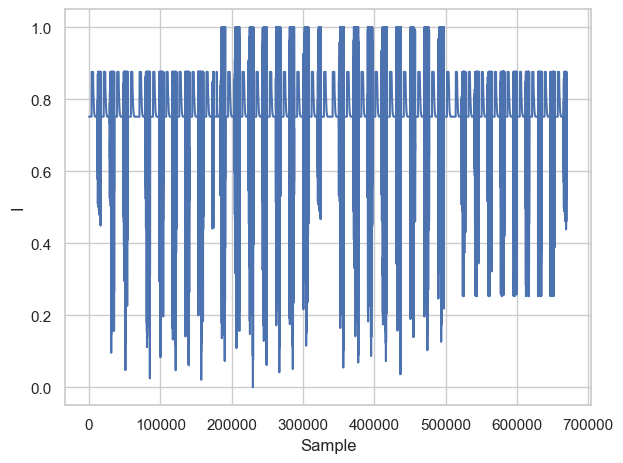

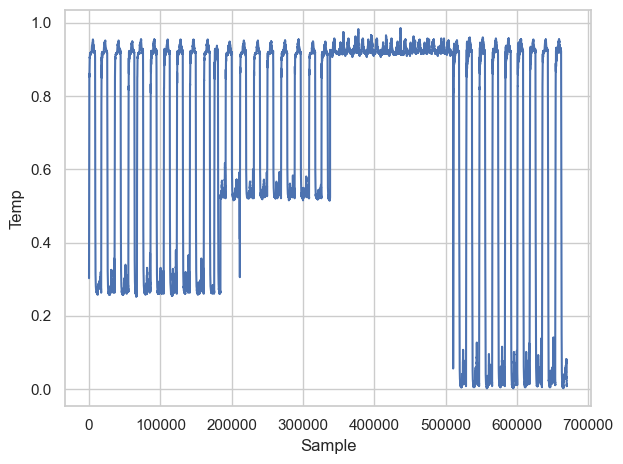

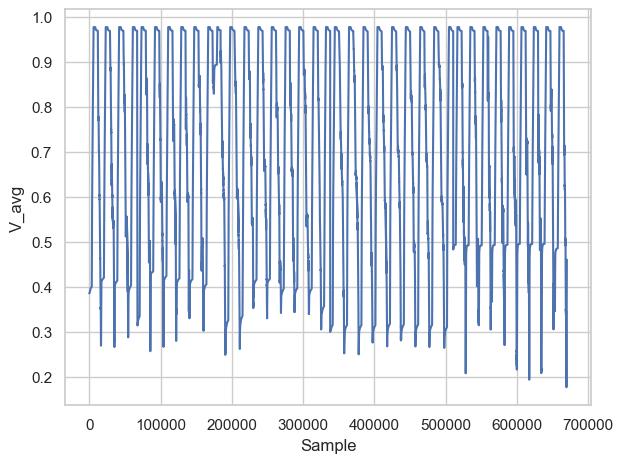

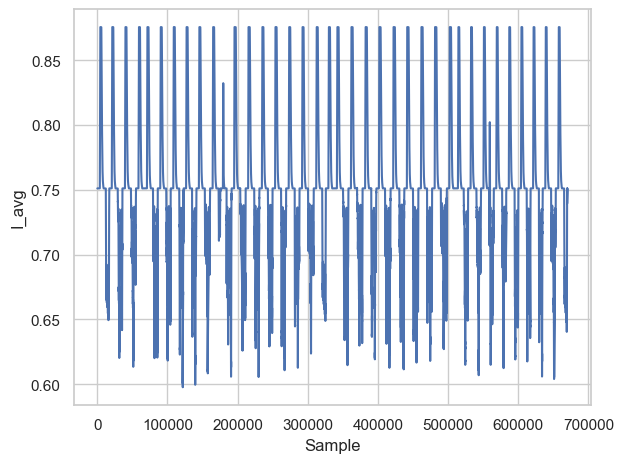

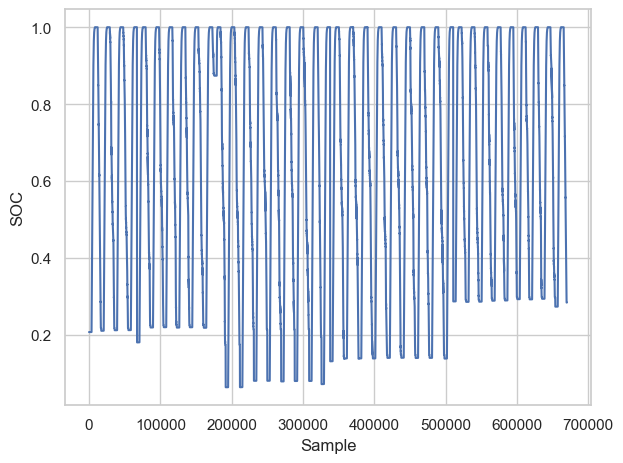

In [9]:
for col in train_raw_data.columns:
    y = train_raw_data[col].to_numpy().flatten()
    x = np.arange(len(y))
    path = os.path.join(cwd, paths.lines_dir, col+'_'+'train_raw_data_line.png')
    get_line(x, y, xlabel='Sample', ylabel=col, path=path)

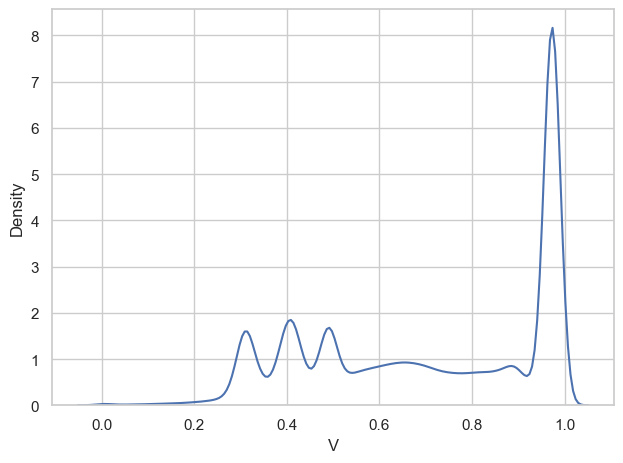

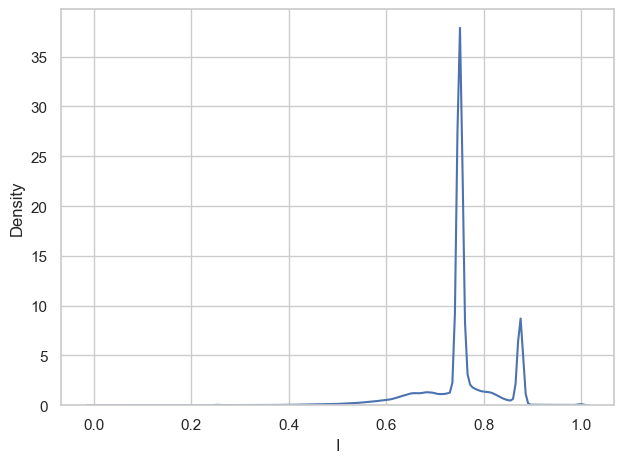

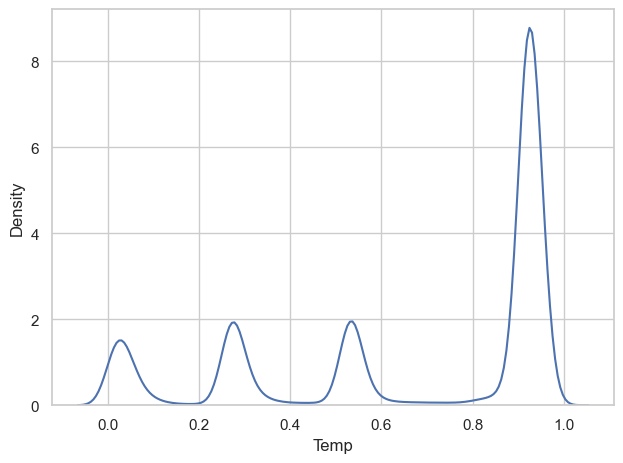

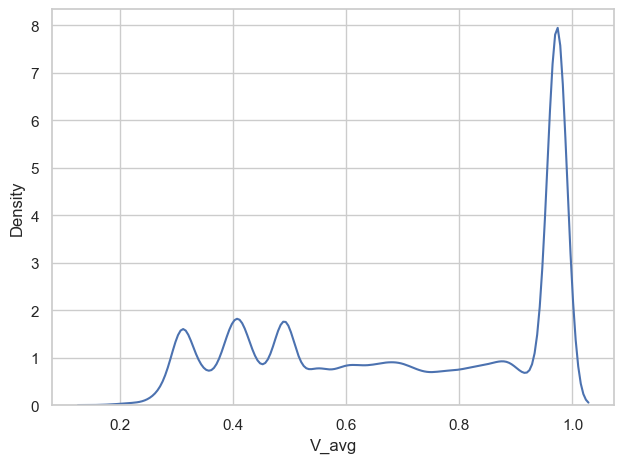

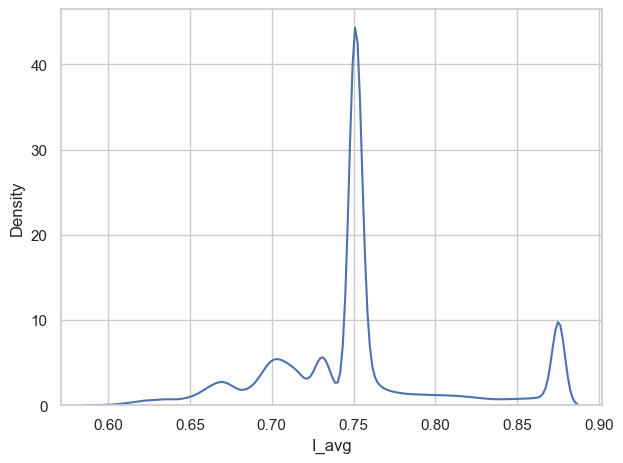

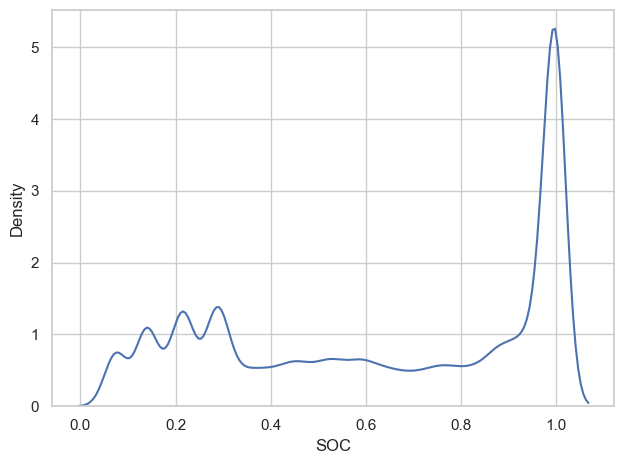

In [10]:
for col in train_raw_data.columns:
    y = train_raw_data[col].to_numpy().flatten()
    path = os.path.join(cwd, paths.kde_dir, col+'_'+'train_raw_data_kde.png')
    get_kde(y, xlabel=col, ylabel='Density', path=path)

In [11]:
val_raw_data = get_dataframe(
    dir_path=val_raw_data_dir, 
    listdir=val_raw_data_list_dir
)

val_raw_data

,V,I,Temp,V_avg,I_avg,SOC
0,0.967308,0.749218,0.005644,0.967308,0.749218,1.000000
1,0.957333,0.746992,0.005644,0.962321,0.748105,0.999990
2,0.953690,0.747098,0.005644,0.959444,0.747769,0.999983
3,0.952046,0.747098,0.005644,0.957594,0.747602,0.999973
4,0.951106,0.747098,0.005644,0.956297,0.747501,0.999963
...,...,...,...,...,...,...
39288,0.481545,0.751020,0.016976,0.463625,0.751020,0.290053
39289,0.481545,0.751020,0.016976,0.463768,0.751020,0.290053
39290,0.481664,0.751020,0.016976,0.463910,0.751020,0.290053
39291,0.481664,0.751020,0.014143,0.464051,0.751020,0.290053


In [12]:
val_raw_data.describe()

,V,I,Temp,V_avg,I_avg,SOC
count,39293.000000,39293.000000,39293.000000,39293.000000,39293.000000,39293.000000
mean,0.732562,0.742404,0.261276,0.735019,0.742196,0.730903
std,0.231193,0.089728,0.387300,0.215372,0.056303,0.247189
min,0.000000,0.253065,0.000000,0.204047,0.598957,0.282253
25%,0.548733,0.725990,0.016976,0.561836,0.712883,0.521799
50%,0.760062,0.751020,0.031141,0.760508,0.732690,0.780140
75%,0.969524,0.770122,0.534296,0.969475,0.751724,0.990010
max,0.979296,0.877404,0.957498,0.977546,0.875482,1.000000


In [13]:
val_raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39293 entries, 0 to 39292
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V       39293 non-null  float64
 1   I       39293 non-null  float64
 2   Temp    39293 non-null  float64
 3   V_avg   39293 non-null  float64
 4   I_avg   39293 non-null  float64
 5   SOC     39293 non-null  float64
dtypes: float64(6)
memory usage: 1.8 MB


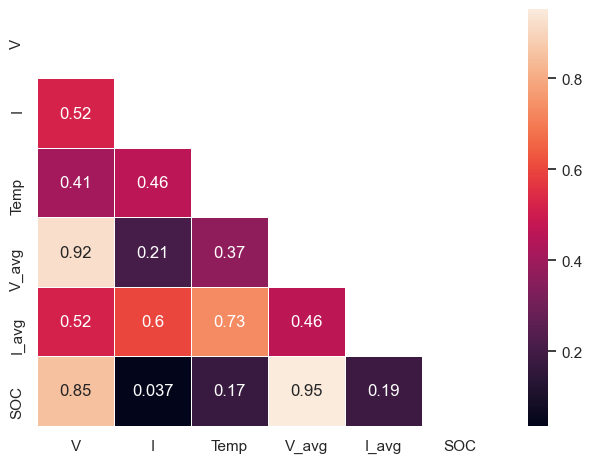

In [14]:
get_heatmap(corr=val_raw_data.corr(), path=os.path.join(cwd, paths.heatmaps_dir, 'val_raw_data_heatmap.png'))

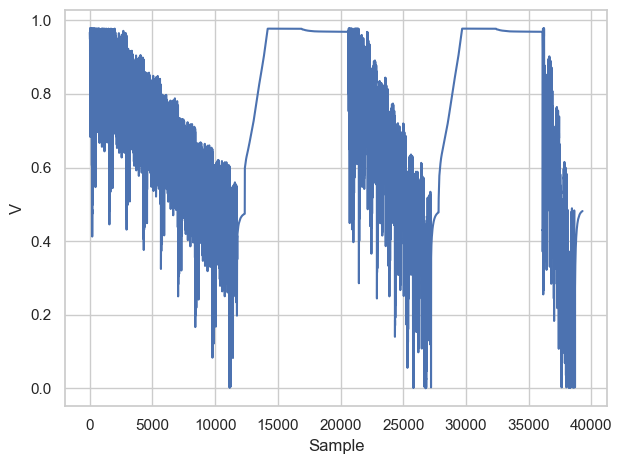

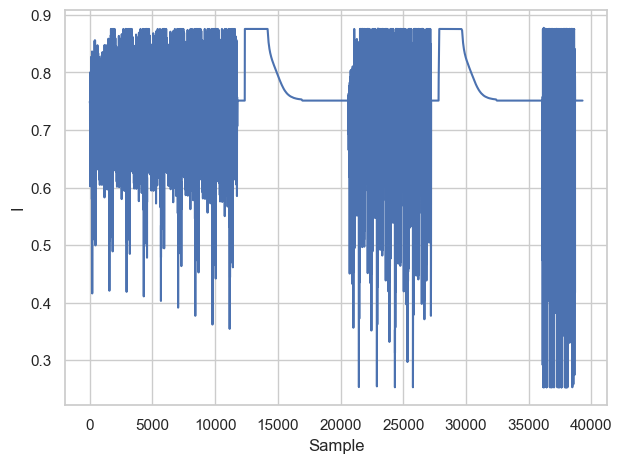

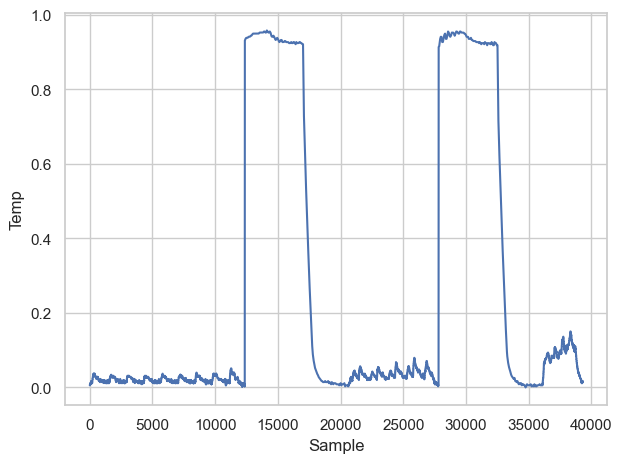

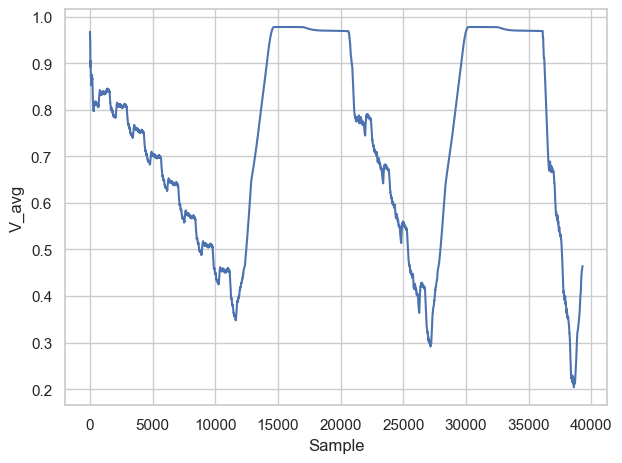

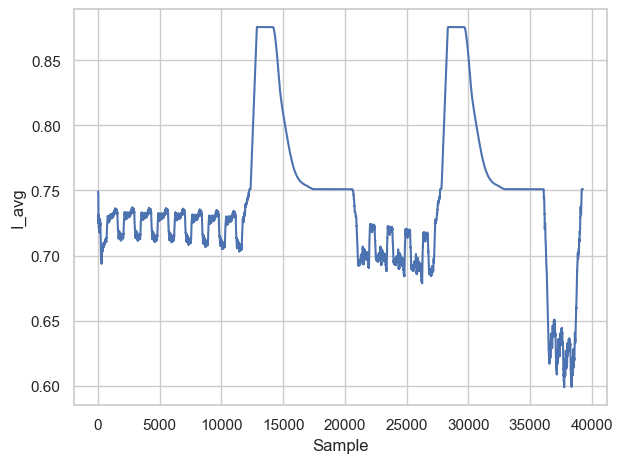

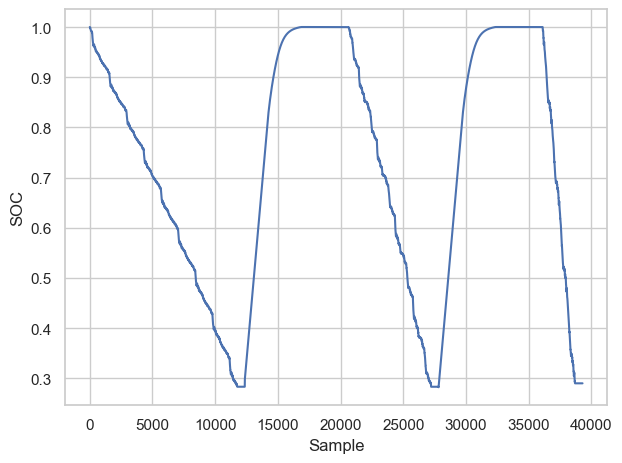

In [15]:
for col in train_raw_data.columns:
    y = val_raw_data[col].to_numpy().flatten()
    x = np.arange(len(y))
    path = os.path.join(cwd, paths.lines_dir, col+'_'+'val_raw_data_line.png')
    get_line(x, y, xlabel='Sample', ylabel=col, path=path)

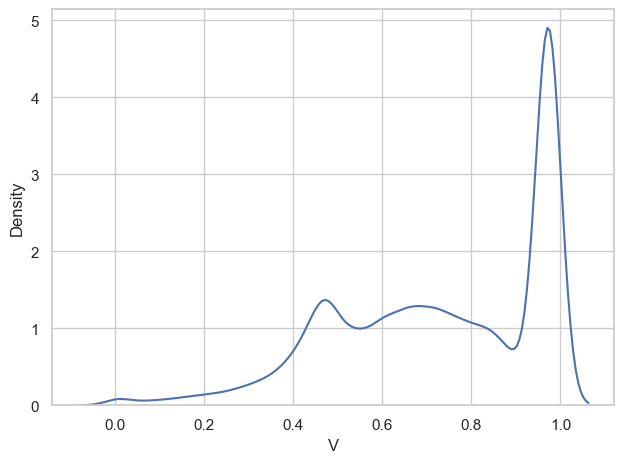

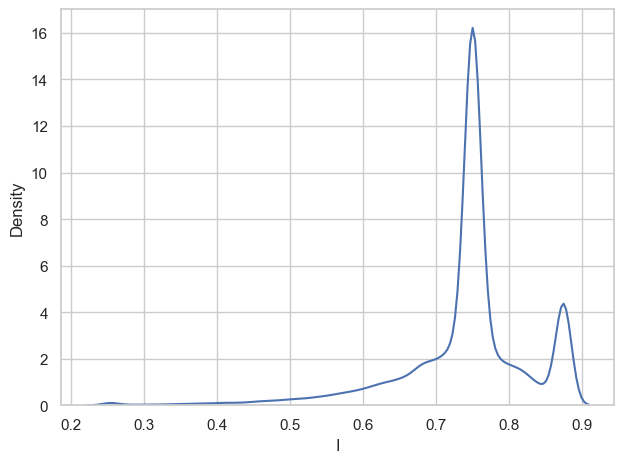

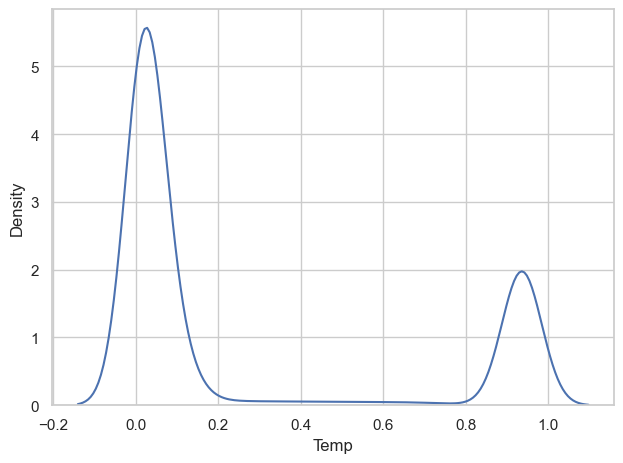

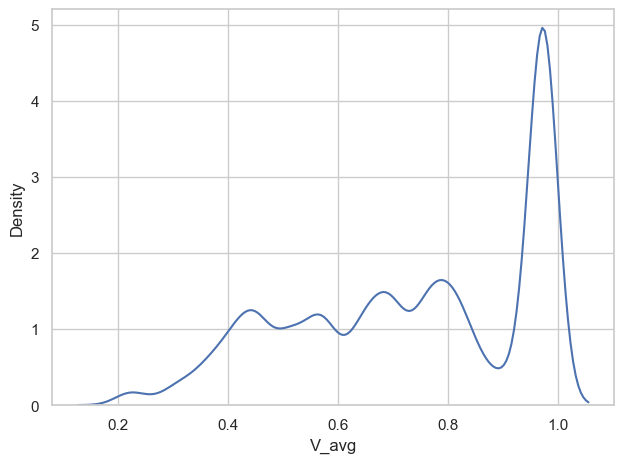

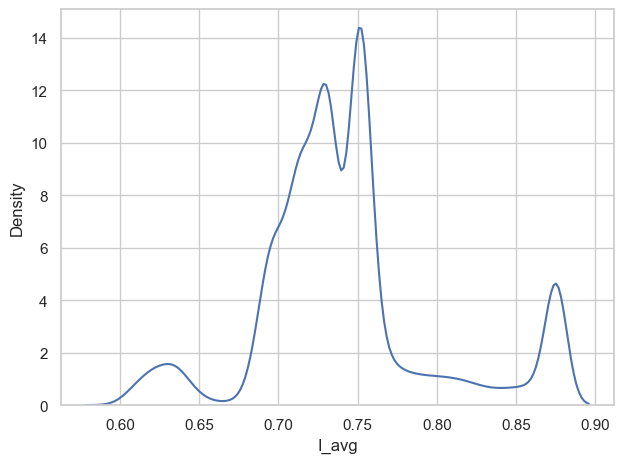

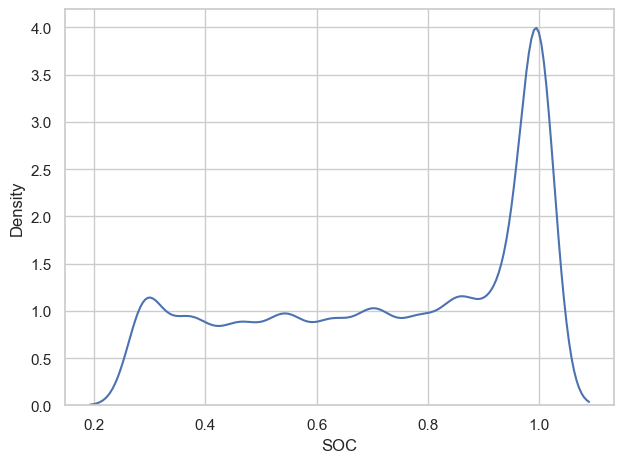

In [16]:
for col in train_raw_data.columns:
    y = val_raw_data[col].to_numpy().flatten()
    path = os.path.join(cwd, paths.kde_dir, col+'_'+'val_raw_data_kde.png')
    get_kde(y, xlabel=col, ylabel='Density', path=path)

In [17]:
test_raw_data = get_dataframe(
    dir_path=test_raw_data_dir, 
    listdir=test_raw_data_list_dir
)

test_raw_data

,V,I,Temp,V_avg,I_avg,SOC
0,0.968130,0.749112,0.260607,0.968130,0.749112,1.000000
1,0.962495,0.746992,0.260607,0.965313,0.748052,0.999990
2,0.961792,0.747098,0.260607,0.964139,0.747734,0.999983
3,0.961555,0.746992,0.260607,0.963493,0.747549,0.999973
4,0.961325,0.747098,0.260607,0.963059,0.747459,0.999963
...,...,...,...,...,...,...
134326,0.298614,0.751020,0.926344,0.292723,0.751020,0.136623
134327,0.298614,0.751020,0.926344,0.292761,0.751020,0.136623
134328,0.298614,0.751020,0.926344,0.292798,0.751020,0.136623
134329,0.298614,0.751020,0.929177,0.292834,0.751020,0.136623


In [18]:
test_raw_data.describe()

,V,I,Temp,V_avg,I_avg,SOC
count,134331.000000,134331.000000,134331.000000,134331.000000,134331.000000,134331.000000
mean,0.735880,0.741786,0.670891,0.739103,0.741623,0.683569
std,0.218539,0.092866,0.273557,0.211364,0.055218,0.278555
min,0.001975,0.005981,0.257774,0.239962,0.593282,0.136580
25%,0.570055,0.717418,0.520643,0.567517,0.714273,0.440257
50%,0.766853,0.751020,0.637657,0.773037,0.732031,0.729197
75%,0.969405,0.769781,0.926344,0.969166,0.751020,0.970433
max,0.980868,0.999987,1.000000,0.977546,0.875470,1.000000


In [19]:
test_raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134331 entries, 0 to 134330
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V       134331 non-null  float64
 1   I       134331 non-null  float64
 2   Temp    134331 non-null  float64
 3   V_avg   134331 non-null  float64
 4   I_avg   134331 non-null  float64
 5   SOC     134331 non-null  float64
dtypes: float64(6)
memory usage: 6.1 MB


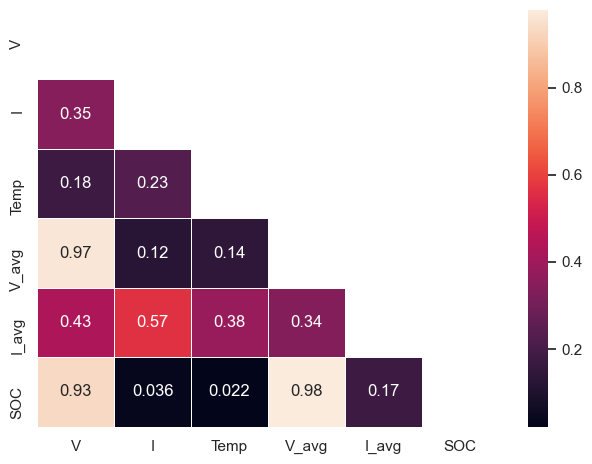

In [20]:
get_heatmap(corr=test_raw_data.corr(), path=os.path.join(cwd, paths.heatmaps_dir, 'test_raw_data_heatmap.png'))

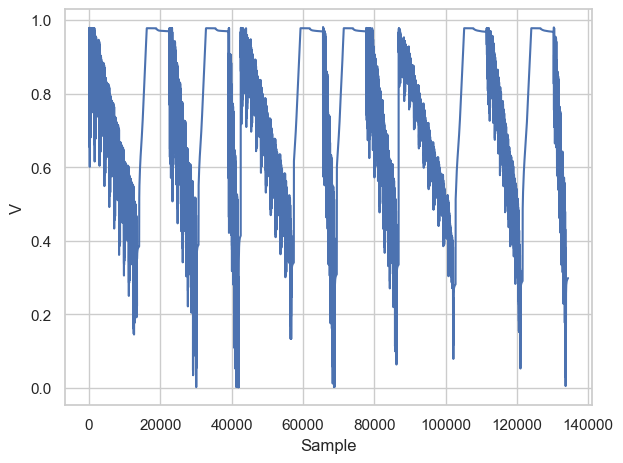

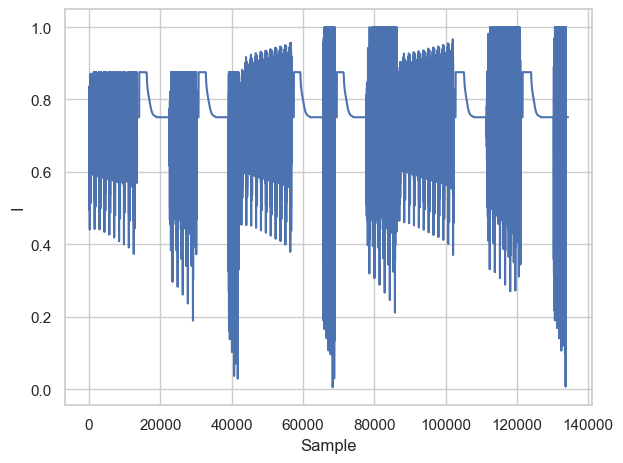

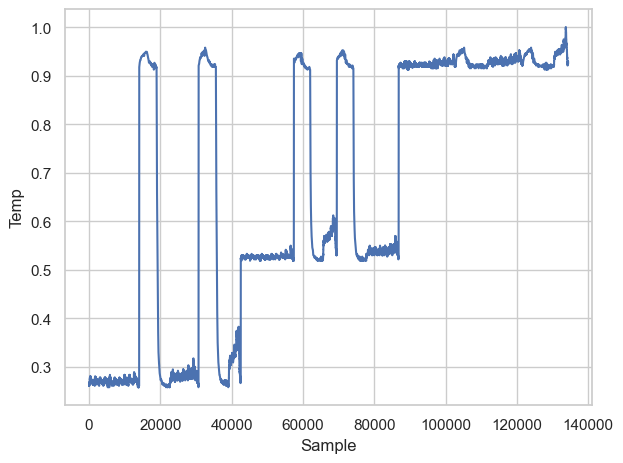

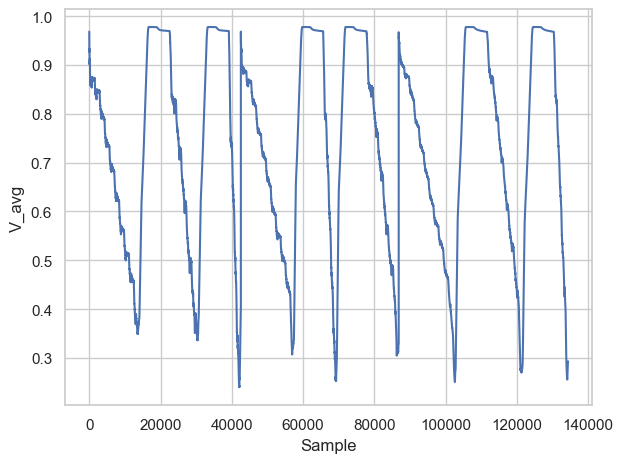

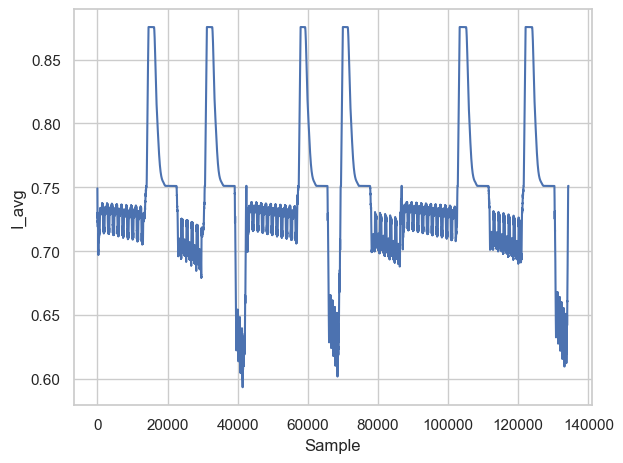

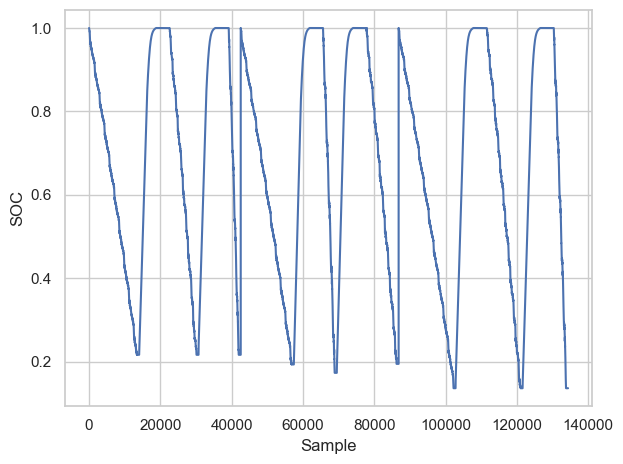

In [21]:
for col in train_raw_data.columns:
    y = test_raw_data[col].to_numpy().flatten()
    x = np.arange(len(y))
    path = os.path.join(cwd, paths.lines_dir, col+'_'+'test_raw_data_line.png')
    get_line(x, y, xlabel='Sample', ylabel=col, path=path)

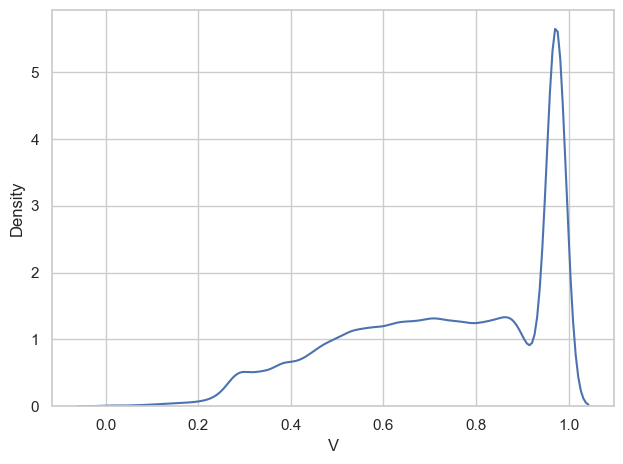

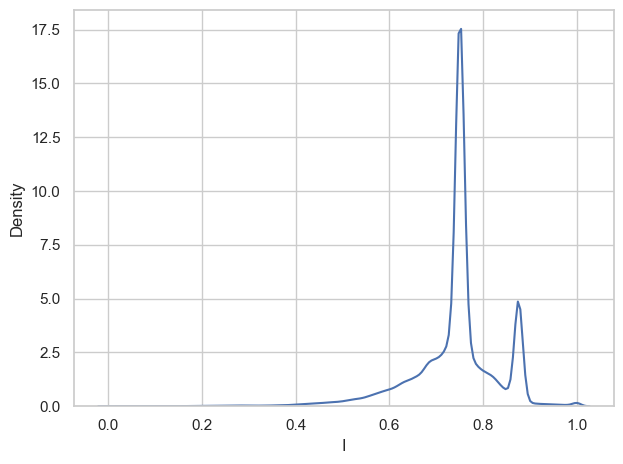

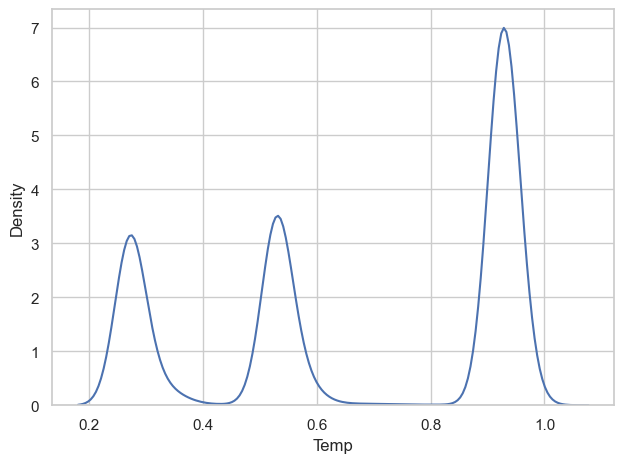

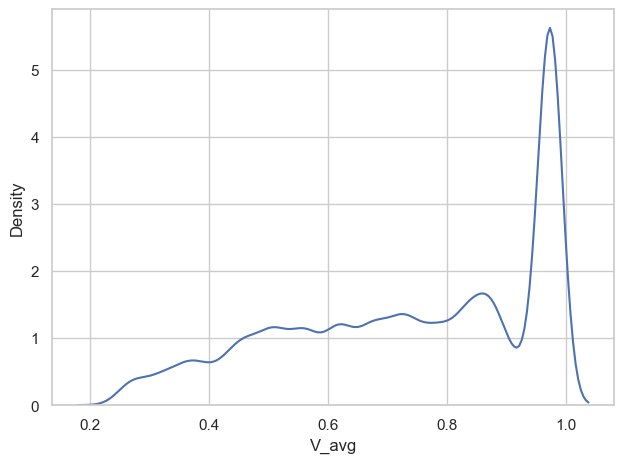

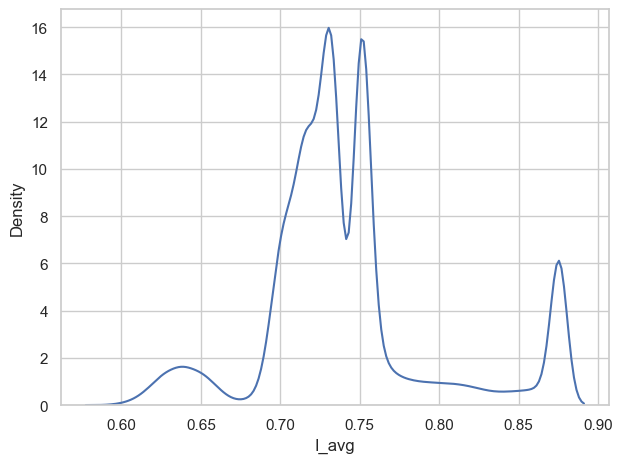

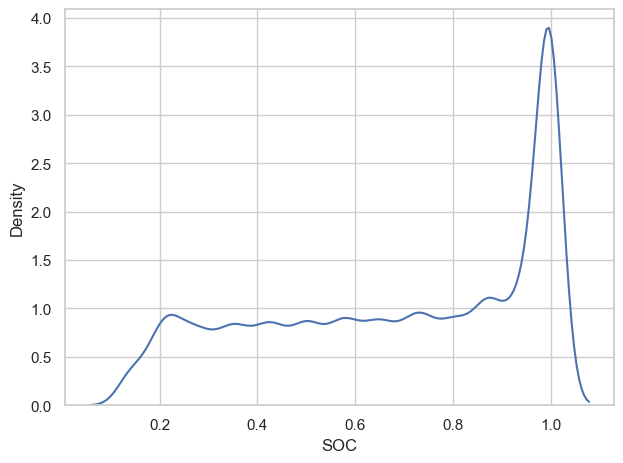

In [22]:
for col in train_raw_data.columns:
    y = test_raw_data[col].to_numpy().flatten()
    path = os.path.join(cwd, paths.kde_dir, col+'_'+'test_raw_data_kde.png')
    get_kde(y, xlabel=col, ylabel='Density', path=path)